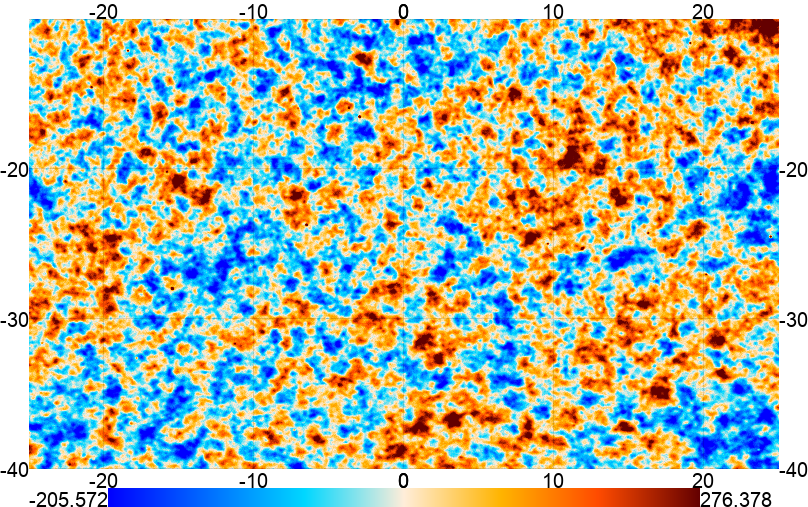

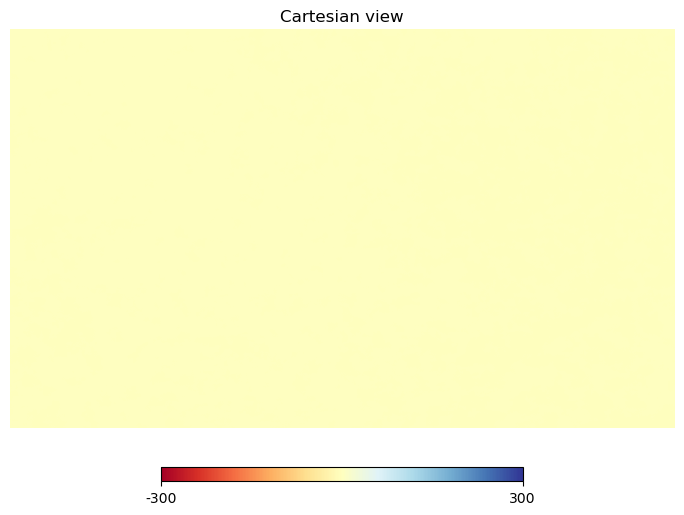

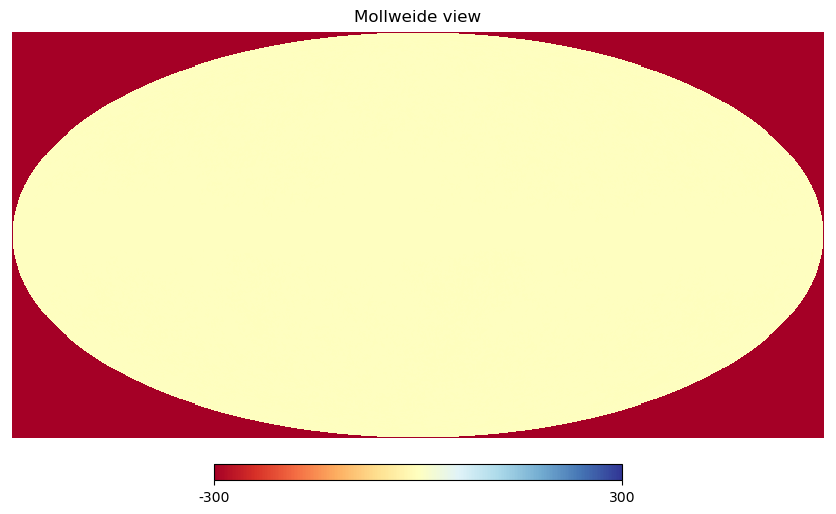

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import time
import sys
from pixell import enmap, enplot, reproject, utils, curvedsky 
from matplotlib import cm, colormaps
from scipy.optimize import curve_fit
from scipy.linalg import sqrtm

path = "/Users/heesunglee/Documents/CS-Projects/act_data/"

# Defines plotting function
def eshow(x,**kwargs): 
    ''' Define a function to help us plot the maps neatly '''
    plots = enplot.get_plots(x, **kwargs)
    enplot.show(plots, method = "ipython")

# Reads in maps of both ndmap(CAR) & HEALPix  
fname_dg = "act_planck_dr5.01_s08s18_AA_f150_night_map_dg_I.fits"
pmap_fname = path + "HFI_SkyMap_143_2048_R2.02_full.fits"

'''make into method?'''
# Set the size of the box in degrees and convert to radians
dec_from, dec_to = np.deg2rad([-40,-10]) ## Inputs declination ()
ra_from, ra_to = np.deg2rad([-25, 25]) ## Input ascension ()
box = [[dec_from,ra_from],[dec_to,ra_to]]

# read in the maps
imap = enmap.read_map(path + fname_dg, box = box)
iheals = hp.read_map(pmap_fname, field=0)

#---------------------------------#
#Convert HEALPix to ndmap map
planck_map = reproject.healpix2map(iheals, imap.shape, imap.wcs, lmax=6000,rot='gal,equ') * 1e6 ## By default in Kelvins, but converts to microKelvins

# Visualize using eshow
eshow(planck_map, **{"downgrade": 2, "colorbar":True, "ticks": 10, })

#----------------------------------#

# Convert an ndmap map to HEALPix
smap_healpix = reproject.map2healpix(imap, nside = 512, lmax = 6000)

# Plot using healpy
lonra = np.sort(imap.box()[:, 1])/utils.degree
latra = np.sort(imap.box()[:, 0])/utils.degree
rang = 300

hp.cartview(smap_healpix, lonra = lonra, latra = latra, min = -rang, max = rang, 
            cmap = colormaps.get_cmap('RdYlBu'))

hp.mollview(smap_healpix, min = -rang, max = rang, 
            cmap = colormaps.get_cmap('RdYlBu'))